# 01 — Views vs Commits per Day: Line Chart with Styles

## What this notebook does

Combines two data sources — newsfeed pageviews and checker submissions —
to compare student activity on a single styled line chart.

## Data

- **Source:** `checking-logs.sqlite` → tables `pageviews` and `checker`
- **Filtered:** only real students (`uid LIKE 'user_%'`)
- **Aggregation:** both pageviews and checker submissions counted per day,
  then merged by date (inner join)

## Key steps

1. Query pageviews and checker timestamps separately
2. Aggregate both series by date
3. Merge into a single DataFrame with columns `count_views` and `count_commits`
4. Plot both on one chart with custom line styles (`r-.o` for views, `b--` for commits)

## Result

A dual-line chart revealing the relationship between newsfeed engagement
and submission activity over time. Days with more than 150 views — 2 in total —
stand out as peaks of unusually high student engagement.

## Tools

`pandas` · `sqlite3` · `matplotlib`

In [1]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('../data/checking-logs.sqlite')

In [ ]:
pageviews_data = pd.read_sql("""
                             SELECT p.datetime
                             FROM pageviews AS p
                             WHERE p.uid LIKE 'user_%'
                             """,
                             conn)
pageviews_data['datetime'] = pd.to_datetime(pageviews_data['datetime'])
pageviews_per_day = pageviews_data['datetime'].dt.date
pageviews_per_day = pageviews_per_day.value_counts().sort_index()
pageviews_per_day.head()

datetime
2020-04-17     1
2020-04-18    23
2020-04-19    15
2020-04-21     3
2020-04-22     1
Name: count, dtype: int64

In [3]:
checker = pd.io.sql.read_sql("""
                             SELECT c.timestamp
                             FROM checker AS c
                             WHERE c.uid LIKE 'user_%'
                             """,
                             conn)
checker['timestamp'] = pd.to_datetime(checker['timestamp'])
checker_date = checker['timestamp'].dt.date
checker_per_day = checker_date.value_counts().sort_index()
checker_per_day.head()


timestamp
2020-04-17    23
2020-04-18    69
2020-04-19    33
2020-04-20    25
2020-04-21    25
Name: count, dtype: int64

In [4]:
checker_n_pageviews_per_day = pd.merge(left=pageviews_per_day, right=checker_per_day, left_index=True, right_index=True, how='inner')
checker_n_pageviews_per_day.columns = ['count_views', 'count_commits']
print(checker_n_pageviews_per_day)
print(len(checker_n_pageviews_per_day))

            count_views  count_commits
datetime                              
2020-04-17            1             23
2020-04-18           23             69
2020-04-19           15             33
2020-04-21            3             25
2020-04-22            1             28
2020-04-23            5             43
2020-04-25            1            104
2020-04-26            8            261
2020-04-28            2              5
2020-04-29            4             17
2020-04-30            9             53
2020-05-01            3             60
2020-05-02            6            242
2020-05-03           19            180
2020-05-04            1             37
2020-05-05            1            139
2020-05-06            3              2
2020-05-07            2             52
2020-05-08           48             87
2020-05-09           19             86
2020-05-10          110            143
2020-05-11          200            186
2020-05-12           85            323
2020-05-13          102  

<Axes: title={'center': 'Views and commits per day'}, xlabel='datetime'>

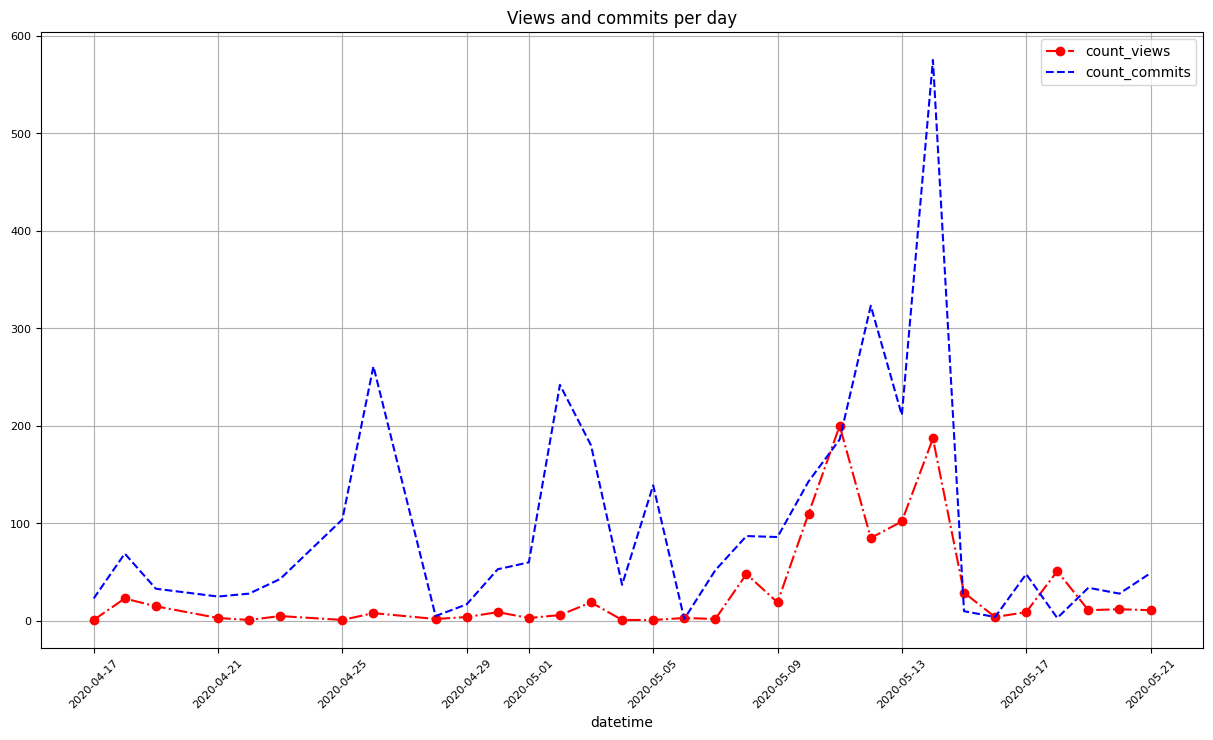

In [5]:
checker_n_pageviews_per_day.plot(figsize=(15,8), fontsize=8, title='Views and commits per day', rot=45, style=['r-.o', 'b--'], grid=True)

In [6]:
checker_n_pageviews_per_day[checker_n_pageviews_per_day['count_views'] > 150].count()

count_views      2
count_commits    2
dtype: int64

In [7]:
conn.close()